In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [4]:
# housing = fetch_california_housing(as_frame=True)
# housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)

# housing_df.head()

#this sklearn import is not working so i used this method which is directly downloading with url

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
housing_df = pd.read_csv(url)

print(housing_df.shape)
print(housing_df.columns)
print(housing_df.head())



(20640, 10)
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558

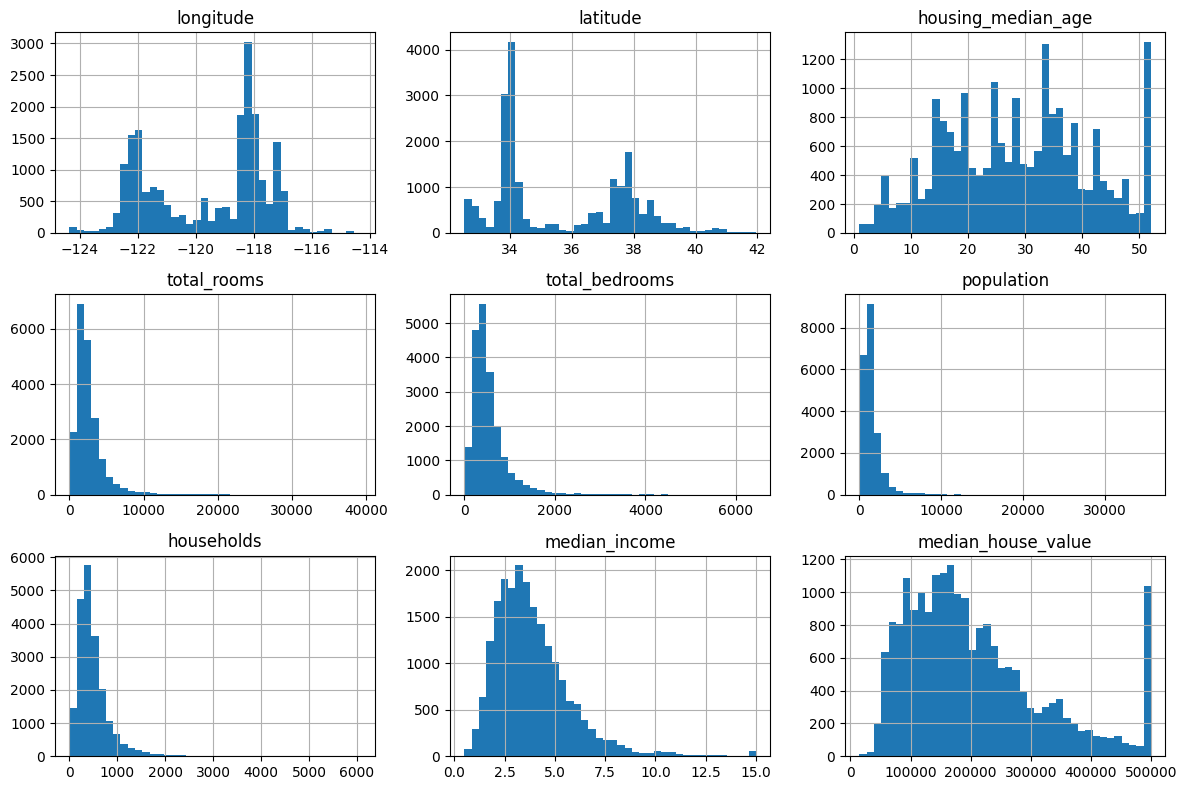

In [5]:
import matplotlib.pyplot as plt
#histograms for all numeric values

housing_df.hist(bins=40,figsize = (12,8))
plt.tight_layout()
plt.show()

#methods to reduce skewness includes log transformation, sqrt transformation , box - cox transformation

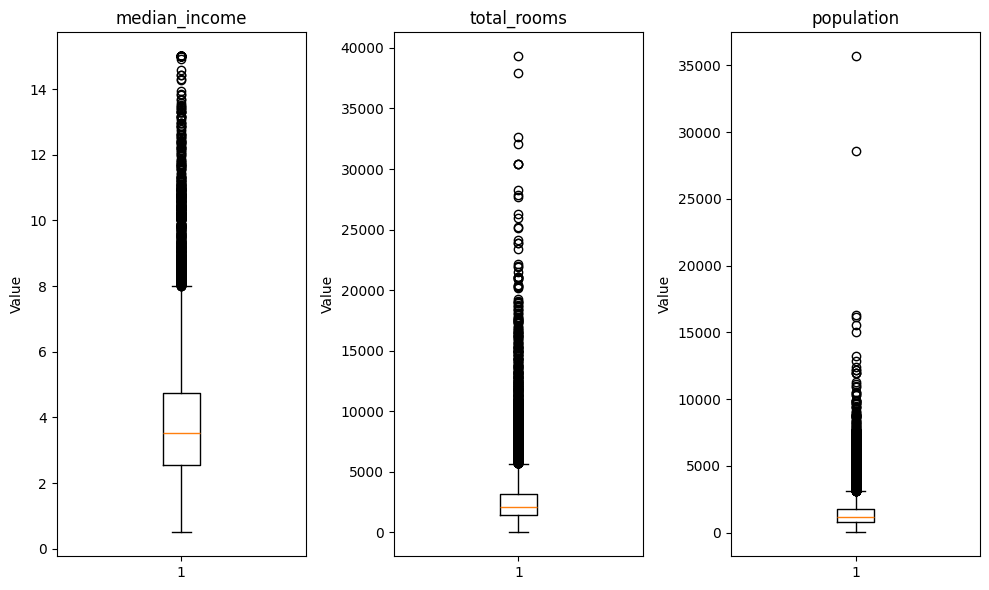

In [6]:
#box plot to detect out liers
cols = ["median_income", "total_rooms", "population"]

plt.figure(figsize=(10,6))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(housing_df[col])
    plt.title(col)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

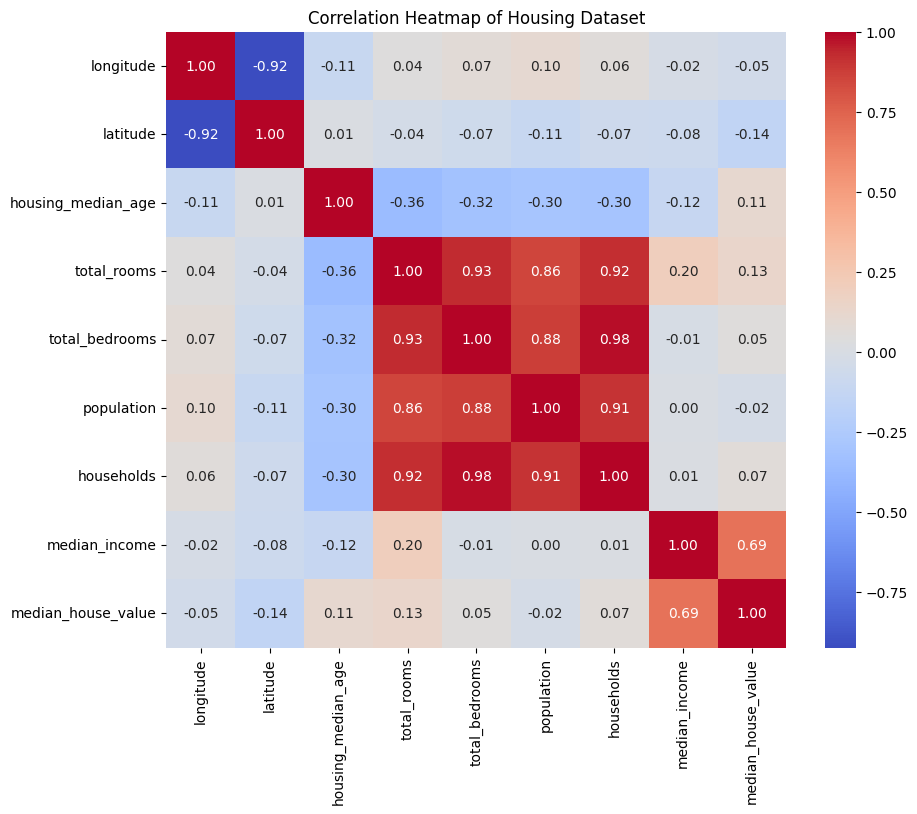

In [7]:
#correlation heatmap
corr_matrix = housing_df.corr(numeric_only=True)
corr_matrix

import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Housing Dataset")
plt.show()


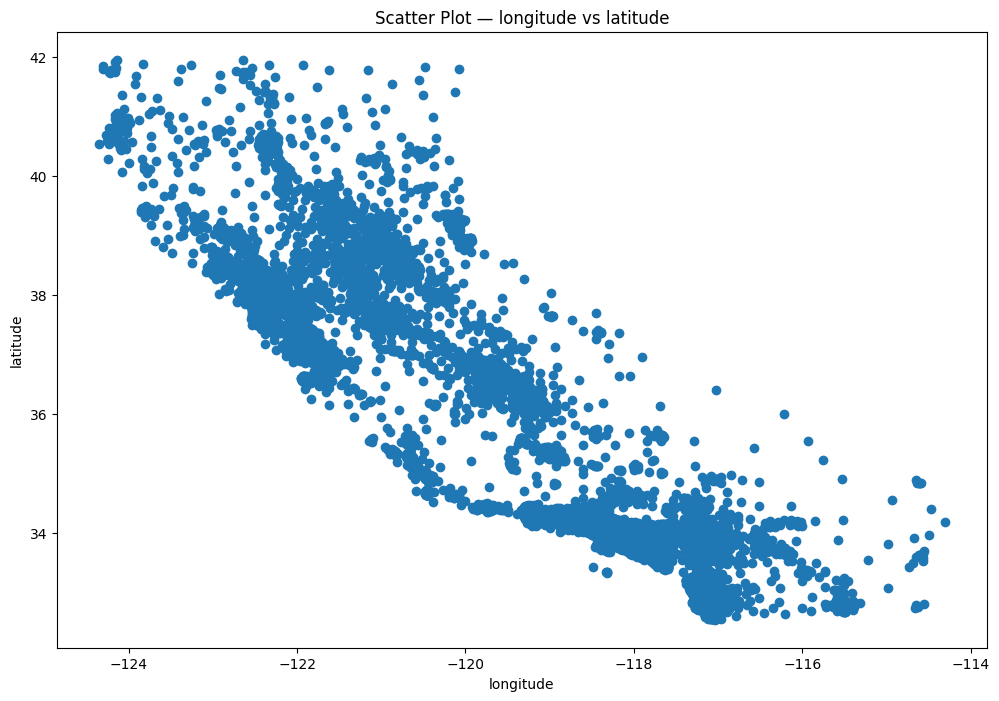

In [8]:
plt.figure(figsize=(12,8))

plt.scatter(housing_df["longitude"], housing_df["latitude"])

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Scatter Plot — longitude vs latitude")
plt.show()


In [9]:
#explain why scaling is required before PCA

# Scaling is required before PCA because PCA is based on variance. Features with larger numeric ranges produce higher variance and dominate the principal components

# example if we have population range from 1 to 20k and latitude from 30 - 40 pca will give more importance to population

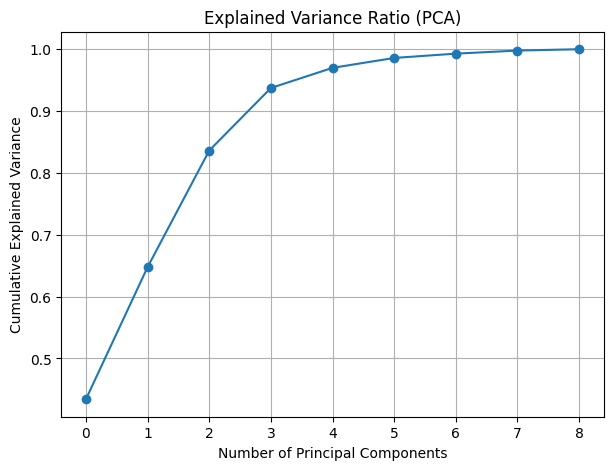

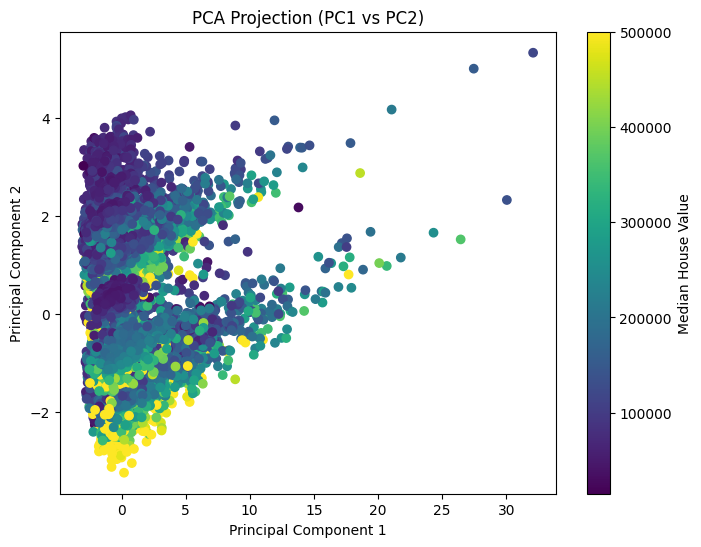

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

numeric_cols = housing_df.select_dtypes(include=np.number).columns
X = housing_df[numeric_cols]

# Imputed missing values with the median before scaling
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(7,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio (PCA)")
plt.grid(True)
plt.show()

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2, columns=["PC1","PC2"])
df_pca["MedHouseVal"] = housing_df["median_house_value"]

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["MedHouseVal"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.colorbar(scatter, label="Median House Value")
plt.show()

In [16]:
#proving that latitudes and longitudes are unnessesary
corr = housing_df.corr(numeric_only=True)

target_corr = corr["median_house_value"].sort_values(ascending=False)
print(target_corr)


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [22]:
df = housing_df
df_clean = df.dropna()

#model pipeline
X = df_clean.drop(columns=["median_house_value","latitude","longitude","ocean_proximity"])
y = df_clean["median_house_value"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipeline.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())])

In [25]:
#coeff printing
coeffs = pipeline.named_steps["lr"].coef_
intercept = pipeline.named_steps["lr"].intercept_

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coeffs
})

print(coef_df)
print("Intercept:", intercept)


              feature   coefficient
0  housing_median_age  23698.726473
1         total_rooms -43121.119876
2      total_bedrooms  42535.167528
3          population -40022.836022
4          households  47710.988704
5       median_income  90685.862704
Intercept: 206864.4131551901


In [26]:
#mse , mbe , r2 calculation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = pipeline.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

n = len(X)
k = X.shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MSE: 5773039795.389614
MAE: 55840.900477850824
R2: 0.5667428164413046
Adjusted R2: 0.5666155500601555


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_test_pred = pipeline.predict(X_test)

print("Test R2:", r2_score(y_test, y_test_pred))
#this is step is for just checking the model

Test R2: 0.5710755317440979


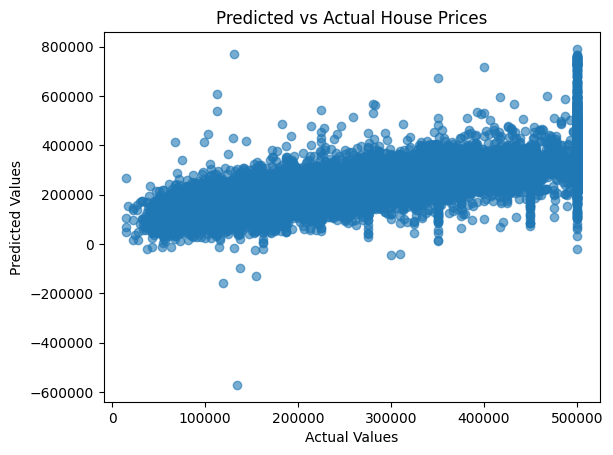

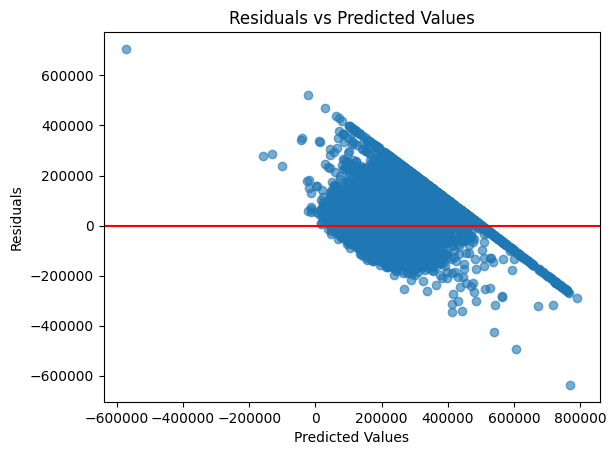

In [31]:
#plotting
plt.scatter(y, y_pred, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual House Prices")
plt.show()
residuals = y - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()
